# 🛍️ SmartCart Starter Notebook
This notebook will guide you through your group project on collaborative filtering and association rule mining for an e-commerce recommender system.

## 📥 Part 1: Data Preprocessing
Steps:
- Load `ecommerce_user_data.csv` and `product_details.csv`
- Merge data if necessary
- Create user-item matrix
- Fill missing ratings with 0
- Group user behavior by category

In [1]:
# Load data
import pandas as pd

user_data = pd.read_csv('./ecommerce_user_data.csv')
product_data = pd.read_csv('./product_details.csv')

print(user_data.head())
print(product_data.head())

  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [2]:
# Create user-item matrix
user_item_matrix = user_data.pivot_table(index='UserID', columns='ProductID', values='Rating')
user_item_matrix_filled = user_item_matrix.fillna(0)
user_item_matrix_filled.head()

ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


In [5]:
# Aggregate user behavior by category
user_category_agg = user_data.groupby(['UserID', 'Category']).agg({'Rating': ['count', 'mean']}).reset_index()
user_category_agg.columns = ['UserID', 'Category', 'TotalInteractions', 'AverageRating']
user_category_agg.head()

,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.666667
1,U000,Clothing,3,1.666667
2,U000,Electronics,3,3.666667
3,U000,Home,2,1.000000
4,U000,Toys,6,3.500000


## 🤝 Part 2: User-Based Collaborative Filtering
Steps:
- Use cosine similarity to compare users
- Recommend top-N products based on similar users
- Evaluate with Precision@K and Coverage

In [3]:
# Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(user_item_matrix_filled)
similarity_df = pd.DataFrame(similarity_matrix, index=user_item_matrix_filled.index, columns=user_item_matrix_filled.index)
similarity_df.head()

UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412,0.161251,0.160096,0.092083,0.238263,0.274844,...,0.241693,0.129483,0.156790,0.132200,0.161478,0.100346,0.126917,0.150727,0.000000,0.104294
U001,0.063071,1.000000,0.190861,0.000000,0.111332,0.009540,0.000000,0.172286,0.167460,0.017593,...,0.121540,0.024075,0.097953,0.007821,0.000000,0.000000,0.193670,0.247805,0.000000,0.000000
U002,0.195522,0.190861,1.000000,0.065094,0.111662,0.050830,0.027756,0.055877,0.000000,0.181229,...,0.144756,0.000000,0.217465,0.000000,0.055992,0.034794,0.194243,0.110030,0.177165,0.000000
U003,0.023466,0.000000,0.065094,1.000000,0.035737,0.104116,0.026650,0.000000,0.025384,0.288009,...,0.243836,0.000000,0.000000,0.074688,0.197121,0.000000,0.054396,0.126773,0.374228,0.250000
U004,0.065412,0.111332,0.111662,0.035737,1.000000,0.159064,0.057144,0.026294,0.195942,0.247023,...,0.062741,0.116202,0.078797,0.048044,0.103747,0.133716,0.124969,0.217464,0.255318,0.172729


In [ ]:
# Create recommendation function
# Find most similar user, recommend products they rated highly that target user hasn’t rated
def recommended_products(userId, user_item_matrix, similarity_df, top_n = 3):
    user_similarity = similarity_df.loc[userId].drop(userId)
    most_similar_user = user_similarity.idxmax()

    target_user_ratings = user_item_matrix.loc[userId]
    similar_user_ratings = user_item_matrix.loc[most_similar_user]
    candidates = similar_user_ratings[(target_user_ratings == 0) & (similar_user_ratings > 0)]
    return candidates.sort_values(ascending=False).head(top_n)

user_one_recommended = recommended_products(userId='U000', user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, top_n=10)
print(user_one_recommended)


ProductID
P0029    5.0
P0051    5.0
P0064    5.0
P0058    4.0
P0060    3.0
P0052    3.0
P0001    3.0
P0066    2.0
P0034    1.0
P0024    1.0
Name: U028, dtype: float64


In [7]:
# Implement evaluation metrics like Precision@K and Coverage
# Example: compare recommended vs actual rated items

def precision_at_k(userId, user_item_matrix, similarity_df, k=10, rating_threshold = 3):
    recommended = recommended_products(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, top_n=k).to_list()

    user_items = user_item_matrix.loc[userId]
    relevant_items = user_items[user_items >= rating_threshold].to_list()

    if(len(recommended) == 0):
        return 0
    hits = len(set(recommended) & set(relevant_items))
    return hits / k 

def global_precision_at_k(user_item_matrix, similarity_df, k=10, rating_threshold = 3):
    total_precision = 0
    user_count = 0

    for userId in user_item_matrix.index:
        precision = precision_at_k(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, k=k, rating_threshold=rating_threshold)
        total_precision += precision
        user_count += 1

    return total_precision / user_count if user_count > 0 else 0

def recall_at_k(userId, user_item_matrix, similarity_df, k=10, rating_threshold = 3):
    recommended = recommended_products(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, top_n=k).to_list()

    user_items = user_item_matrix.loc[userId]
    relevant_items = user_items[user_items >= rating_threshold].to_list()

    if(len(relevant_items) == 0):
        return 0
    hits = len(set(recommended) & set(relevant_items))
    return hits / len(relevant_items)

def global_recall_at_k(user_item_matrix, similarity_df, k=10, rating_threshold = 3):
    total_recall = 0
    user_count = 0

    for userId in user_item_matrix.index:
        recall = recall_at_k(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, k=k, rating_threshold=rating_threshold)
        total_recall += recall
        user_count += 1

    return total_recall / user_count if user_count > 0 else 0

def MAP_at_k(userId, user_item_matrix, similarity_df, k=10, rating_threshold = 3):
    recommended = recommended_products(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, top_n=k).to_list()

    user_items = user_item_matrix.loc[userId]
    relevant_items = user_items[user_items >= rating_threshold].to_list()

    if(len(recommended) == 0 or len(relevant_items) == 0):
        return 0

    hits = 0
    sum_precisions = 0
    for i in range(len(recommended)):
        if recommended[i] in relevant_items:
            hits += 1
            sum_precisions += hits / (i + 1)

    return sum_precisions / min(len(relevant_items), k)

def global_MAP_at_k(user_item_matrix, similarity_df, k=10, rating_threshold = 3):
    total_MAP = 0
    user_count = 0

    for userId in user_item_matrix.index:
        MAP = MAP_at_k(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, k=k, rating_threshold=rating_threshold)
        total_MAP += MAP
        user_count += 1

    return total_MAP / user_count if user_count > 0 else 0

def coverage(user_item_matrix, similarity_df, k=10):
    all_recommended = set()
    for userId in user_item_matrix.index:
        recommended = recommended_products(userId=userId, user_item_matrix=user_item_matrix, similarity_df=similarity_df, top_n=k).index.to_list()
        all_recommended.update(recommended)
    # find total unique items in the user-item matrix
    missing_items = set(user_item_matrix.columns) - all_recommended
    return len(all_recommended) / user_item_matrix.shape[1], missing_items

k = 5
precision_at_k_value = precision_at_k(userId='U000', user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)
global_precision_at_k_value = global_precision_at_k(user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)
recall_at_k_value = recall_at_k(userId='U000', user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)
global_recall_at_k_value = global_recall_at_k(user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)
MAP_at_k_value = MAP_at_k(userId='U000', user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)
global_MAP_at_k_value = global_MAP_at_k(user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)

coverage_value, missing_items = coverage(user_item_matrix=user_item_matrix_filled, similarity_df=similarity_df, k=k)

print("User 0 precision@k: %.2f%%" % (precision_at_k_value * 100))
print("User 0 recall@k: %.2f%%" % (recall_at_k_value * 100))
print("User 0 MAP@k: %.2f%%" % (MAP_at_k_value * 100))
print("Global precision@k: %.2f%%" % (global_precision_at_k_value * 100))
print("Global recall@k: %.2f%%" % (global_recall_at_k_value * 100))
print("Global MAP@k: %.2f%%" % (global_MAP_at_k_value * 100))
print("Coverage: %.2f%%" % (coverage_value * 100))
print("Missing items from recommendations:", missing_items)

User 0 precision@k: 60.00%
User 0 recall@k: 21.43%
User 0 MAP@k: 100.00%
Global precision@k: 43.20%
Global recall@k: 29.96%
Global MAP@k: 76.16%
Coverage: 91.00%
Missing items from recommendations: {'P0067', 'P0045', 'P0093', 'P0000', 'P0081', 'P0054', 'P0080', 'P0099', 'P0035'}


## 🔍 Part 3: Association Rule Mining (Apriori)
Steps:
- Convert user-product interactions to transaction format
- Apply Apriori algorithm to find frequent itemsets
- Generate association rules (support, confidence, lift)

In [31]:
# Convert to transaction format
from mlxtend.preprocessing import TransactionEncoder
transactions = user_data.groupby('UserID')['ProductID'].apply(list).tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

In [32]:
# Apply Apriori and generate rules
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(df_trans, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift
0,(P0000),(P0008),0.06,0.500000,2.777778
1,(P0000),(P0023),0.06,0.500000,3.125000
2,(P0000),(P0030),0.06,0.500000,2.272727
3,(P0000),(P0071),0.06,0.500000,2.777778
4,(P0091),(P0001),0.08,0.571429,3.174603


## 📊 Part 4: Visualization
Steps:
- Plot user similarity heatmap
- Plot top frequent itemsets
- Visualize top recommendations

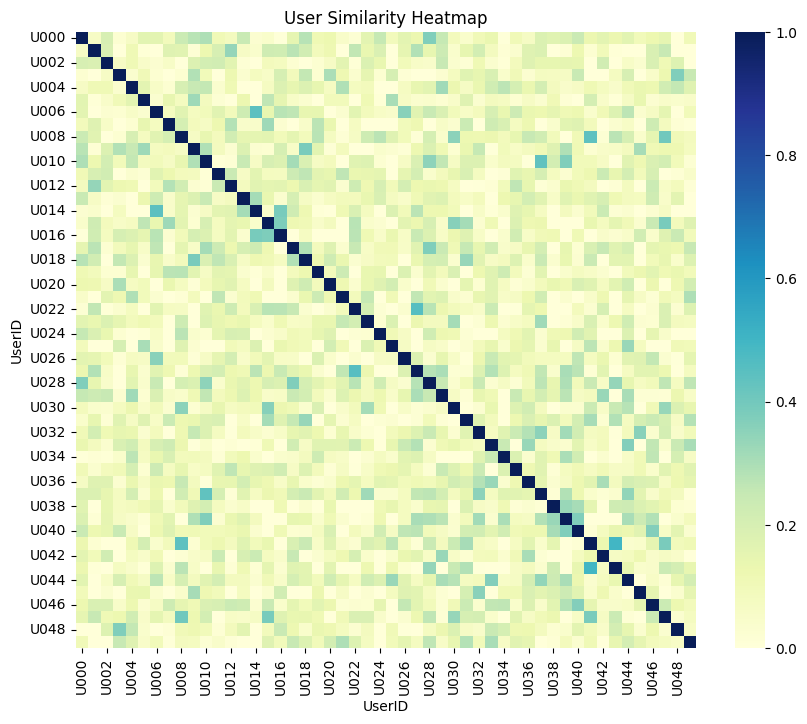

In [33]:
# Heatmap of user similarity
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, cmap='YlGnBu')
plt.title('User Similarity Heatmap')
plt.show()

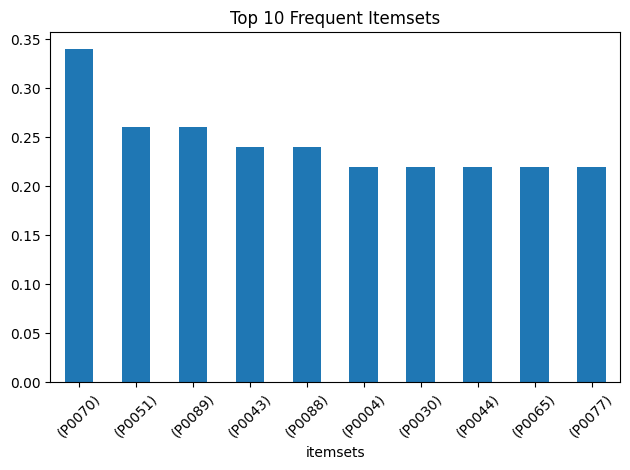

In [34]:
# Frequent itemsets bar chart
frequent_itemsets.nlargest(10, 'support').plot(kind='bar', x='itemsets', y='support', legend=False)
plt.title('Top 10 Frequent Itemsets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🧠 Part 5: Conceptual Questions
Answer the following questions in your report:
1. How does data sparsity affect performance?
2. What kinds of product bundles were discovered?
3. What improvements would you suggest for real-world deployment?